In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted!")

Mounted at /content/drive
Google Drive mounted!


In [ ]:
import os
BASEDIR = '/content/drive/MyDrive/ForestFireDataset/'
print("BASEDIR:", BASEDIR)
print("Contents:", os.listdir(BASEDIR))

BASEDIR: /content/drive/MyDrive/ForestFireDataset/
Contents: ['train']


In [ ]:
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

all_image_paths = []
all_labels = []

for class_name in ['fire', 'nofire']:
    class_dir = os.path.join(BASEDIR, 'train', class_name)
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        paths = glob.glob(os.path.join(class_dir, ext))
        all_image_paths.extend(paths)
        all_labels.extend([class_name] * len(paths))

df = pd.DataFrame({'path': all_image_paths, 'label': all_labels})
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label'])

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 2341, Val: 293, Test: 293


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGESIZE = (256, 256)
BATCHSIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

traingen = datagen.flow_from_dataframe(
    df_train,
    directory=BASEDIR,
    x_col='path', y_col='label',
    target_size=IMAGESIZE, batch_size=BATCHSIZE,
    class_mode='categorical', shuffle=True
)

valgen = datagen.flow_from_dataframe(
    df_val,
    directory=BASEDIR,
    x_col='path', y_col='label',
    target_size=IMAGESIZE, batch_size=BATCHSIZE,
    class_mode='categorical', shuffle=False
)

testgen = datagen.flow_from_dataframe(
    df_test,
    directory=BASEDIR,
    x_col='path', y_col='label',
    target_size=IMAGESIZE, batch_size=BATCHSIZE,
    class_mode='categorical', shuffle=False
)

Found 2341 validated image filenames belonging to 2 classes.
Found 293 validated image filenames belonging to 2 classes.
Found 293 validated image filenames belonging to 2 classes.


In [ ]:
def build_model2_mhcnnfd(input_shape=(256, 256, 3), num_classes=2):
    inputs = tf.keras.Input(shape=input_shape)

    # DEEPER CONV BLOCKS: 64→128→256→128→64 (vs Model1: 32→48→56→64→32)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='valid', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(256, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(64, (3, 3), padding='valid', activation='relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # SAME DENSE HEAD as Model1
    x = tf.keras.layers.Dense(64, activation='selu')(x)
    x = tf.keras.layers.Dense(56, activation='selu')(x)
    x = tf.keras.layers.Dense(32, activation='selu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

model2 = build_model2_mhcnnfd()
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │         3,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751,642 (2.87 MB)

 Trainable params: 750,490 (2.86 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

history = model2.fit(
    traingen,
    validation_data=valgen,
    epochs=40,
    callbacks=[tf.keras.callbacks.LearningRateScheduler(lr_scheduler)]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 1047s 14s/step - accuracy: 0.8145 - loss: 0.4894 - val_accuracy: 0.5666 - val_loss: 0.8321 - learning_rate: 0.0010
Epoch 2/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 44s 589ms/step - accuracy: 0.9160 - loss: 0.2513 - val_accuracy: 0.7747 - val_loss: 0.4539 - learning_rate: 0.0010
Epoch 3/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 605ms/step - accuracy: 0.9224 - loss: 0.2255 - val_accuracy: 0.5256 - val_loss: 0.9457 - learning_rate: 0.0010
Epoch 4/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 608ms/step - accuracy: 0.9407 - loss: 0.1868 - val_accuracy: 0.8362 - val_loss: 0.3843 - learning_rate: 0.0010
Epoch 5/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 606ms/step - accuracy: 0.9369 - loss: 0.2124 - val_accuracy: 0.7577 - val_loss: 0.5900 - learning_rate: 0.0010
Epoch 6/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 50s 672ms/step - accuracy: 0.9321 - loss: 0.2142 - val_accuracy: 0.4437 - val_loss: 1.3884 - learning_rate: 0.0010
Epoch 7/40
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 604ms/step - accuracy: 0.9381 - loss: 0.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

test_loss, test_accuracy = model2.evaluate(testgen, verbose=0)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

y_pred = model2.predict(testgen, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = testgen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes,
                          target_names=list(testgen.class_indices.keys())))

Test Accuracy: 96.93%
Test Loss: 0.0711

Classification Report:
              precision    recall  f1-score   support

        fire       0.98      0.97      0.97       166
      nofire       0.96      0.97      0.96       127

    accuracy                           0.97       293
   macro avg       0.97      0.97      0.97       293
weighted avg       0.97      0.97      0.97       293



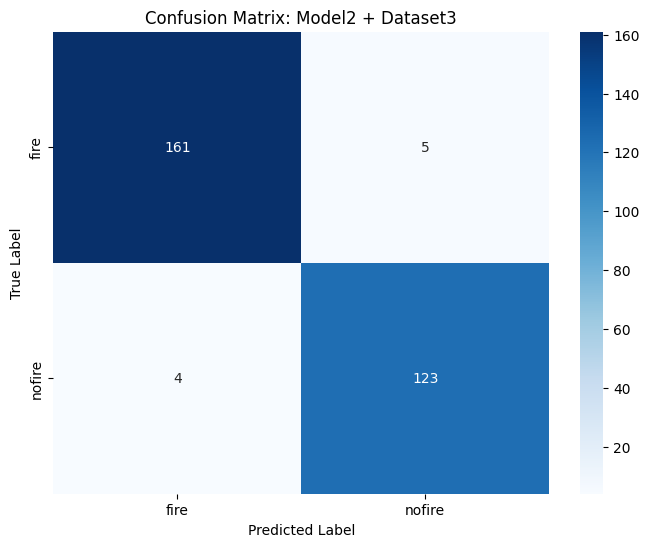

False Negatives (Fire→NoFire): 5
False Positives (NoFire→Fire): 4


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['fire', 'nofire'],
            yticklabels=['fire', 'nofire'])
plt.title('Confusion Matrix: Model2 + Dataset3')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"False Negatives (Fire→NoFire): {cm[0,1]}")
print(f"False Positives (NoFire→Fire): {cm[1,0]}")

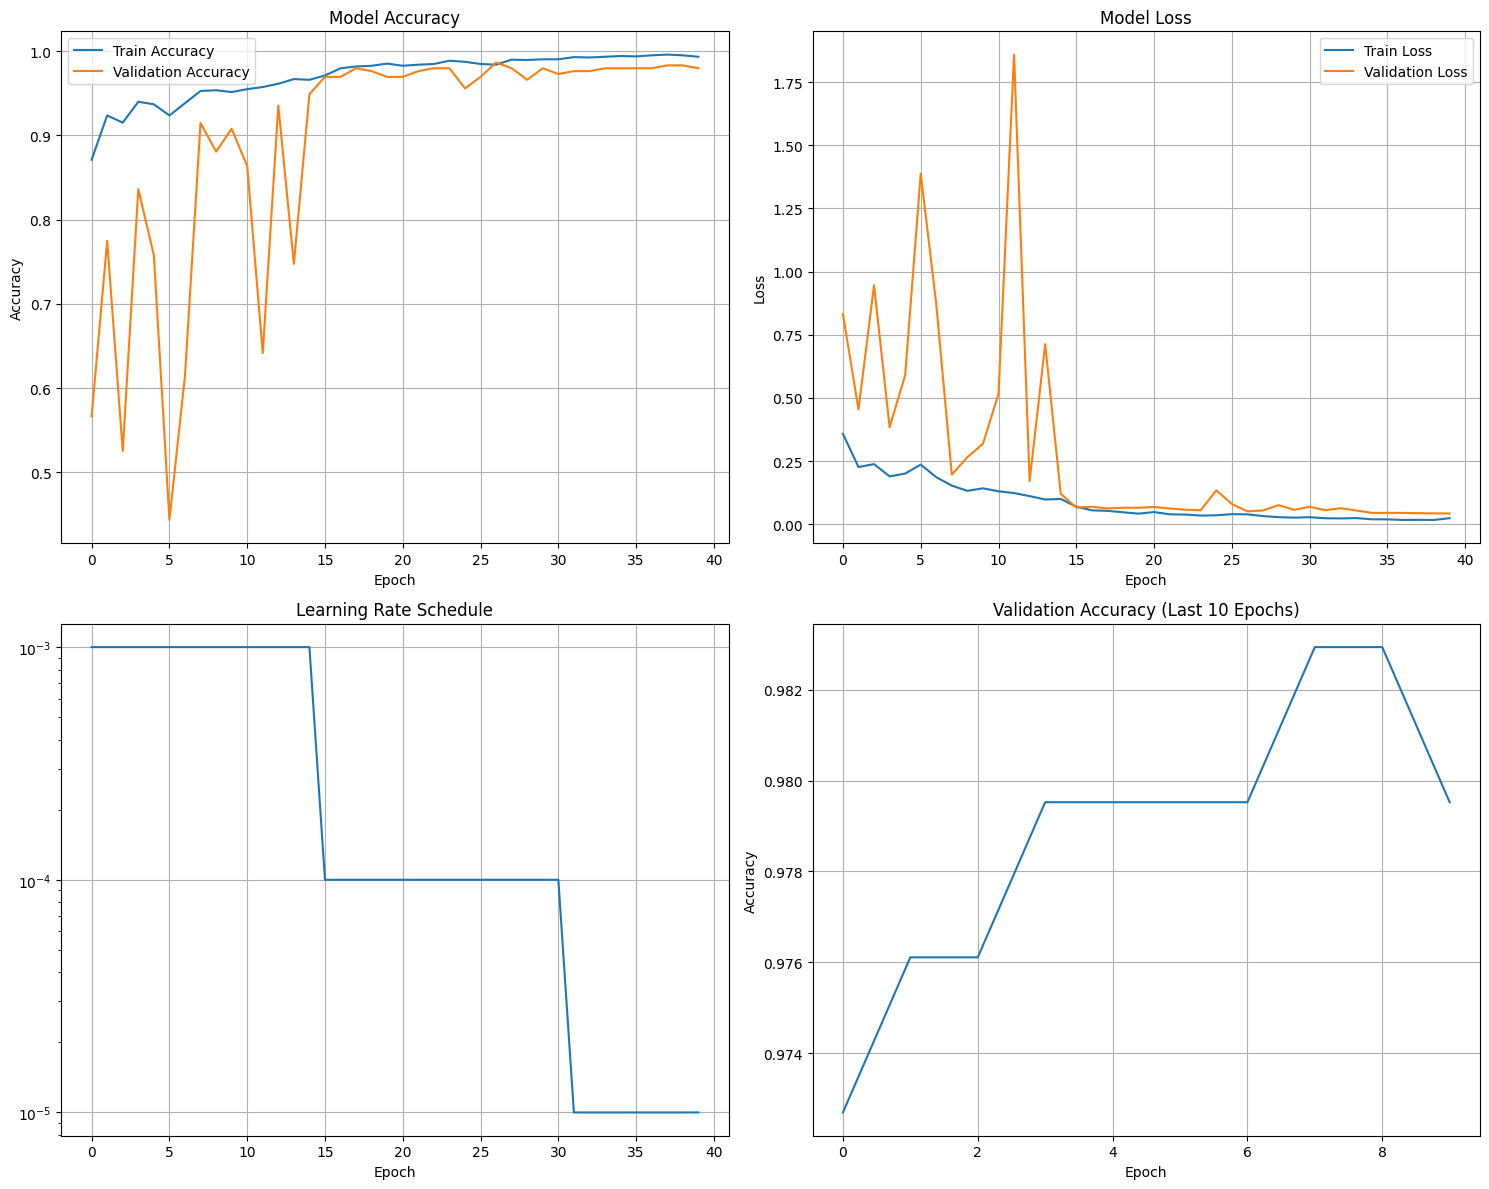

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0,0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0,0].set_title('Model Accuracy')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(history.history['loss'], label='Train Loss')
axes[0,1].plot(history.history['val_loss'], label='Validation Loss')
axes[0,1].set_title('Model Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True)

lr_values = [lr_scheduler(i) for i in range(len(history.history['loss']))]
axes[1,0].plot(lr_values)
axes[1,0].set_title('Learning Rate Schedule')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_yscale('log')
axes[1,0].grid(True)

axes[1,1].plot(history.history['val_accuracy'][-10:])
axes[1,1].set_title('Validation Accuracy (Last 10 Epochs)')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
print("Model2 + Dataset3 Performance Summary")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Samples:  {len(y_true)}")
print(f"Fire Support:  {np.sum(y_true==0)}")
print(f"NoFire Support:{np.sum(y_true==1)}")
print(f"False Negatives:{cm[0,1]}")
print(f"False Positives:{cm[1,0]}")
print("\nTraining Complete.")

Model2 + Dataset3 Performance Summary
Test Accuracy: 96.93%
Test Loss:     0.0711
Test Samples:  293
Fire Support:  0
NoFire Support:0
False Negatives:5
False Positives:4

Training Complete.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


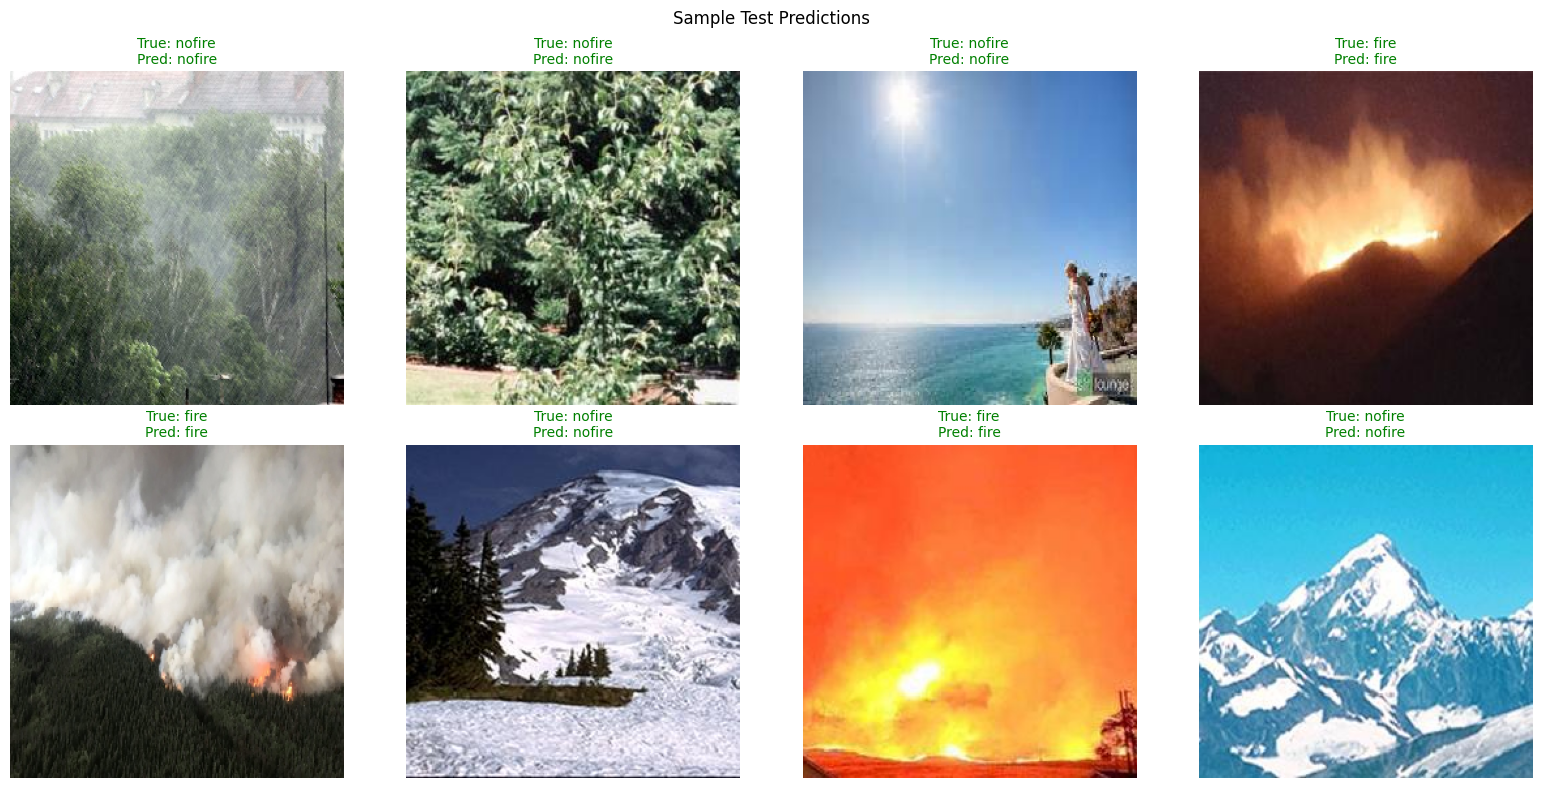

In [ ]:
testgen.reset()
images, labels = next(testgen)
preds = model2.predict(images)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(8):
    ax = axes[i//4, i%4]
    ax.imshow(images[i])
    true_label = 'fire' if np.argmax(labels[i]) == 0 else 'nofire'
    pred_label = 'fire' if np.argmax(preds[i]) == 0 else 'nofire'
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Test Predictions')
plt.tight_layout()
plt.show()